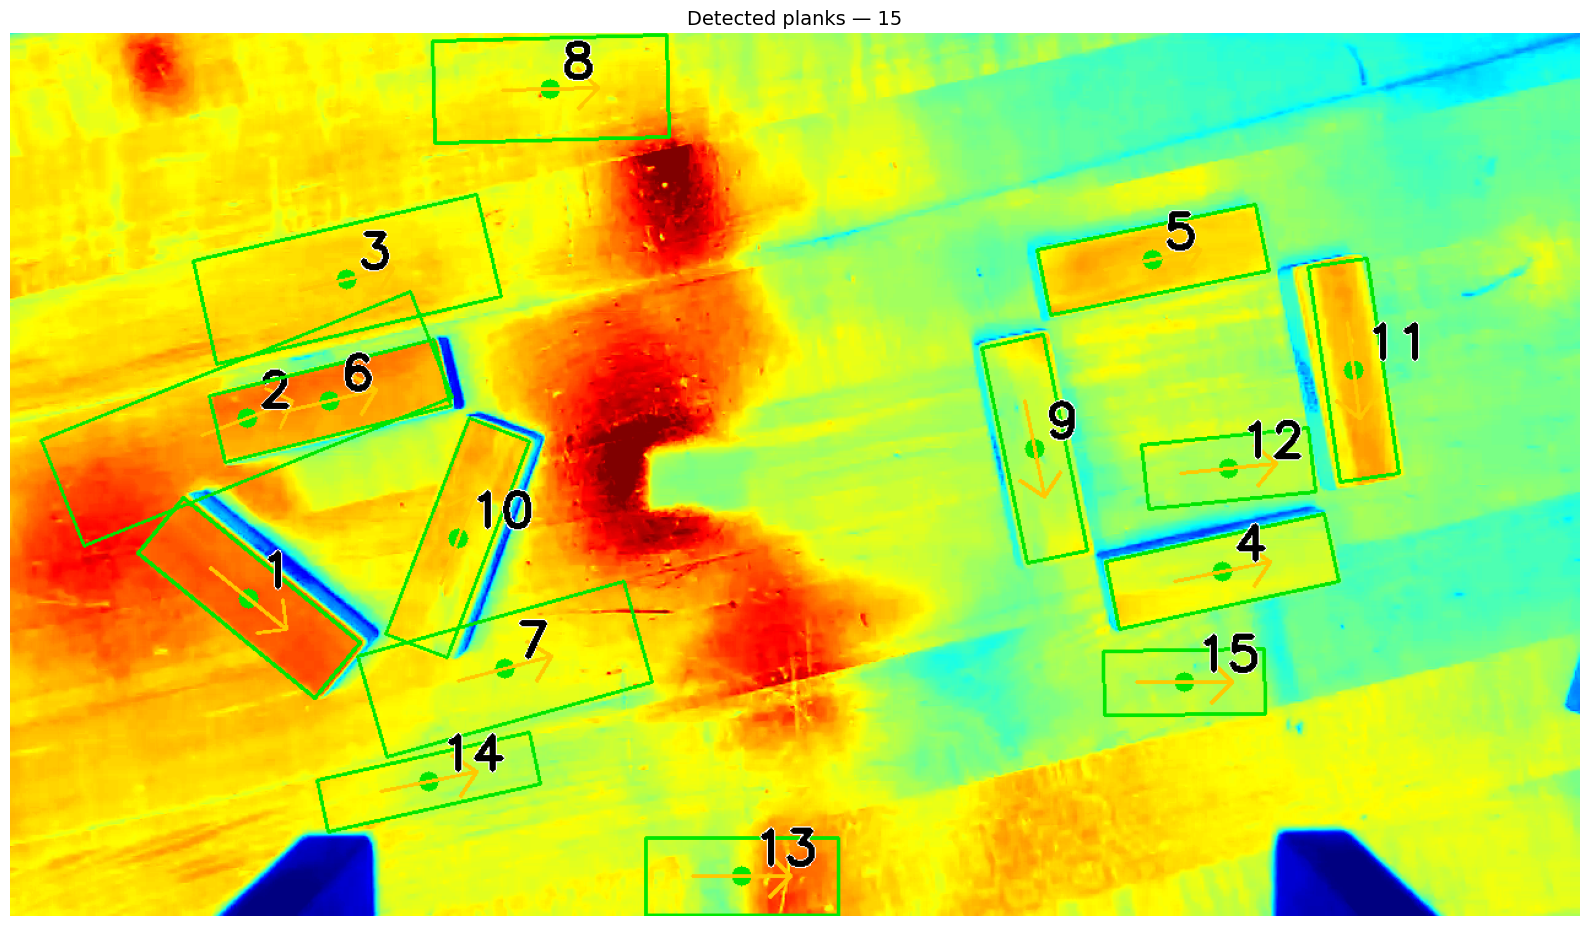

Saved to detected_planks.png
Detected 15 planks
  Plank  1: cx= 194.9  cy= 461.0  angle=  39.19°
  Plank  2: cx= 193.3  cy= 314.8  angle= -21.89°
  Plank  3: cx= 275.0  cy= 201.2  angle= -13.24°
  Plank  4: cx= 988.2  cy= 439.4  angle= -12.26°
  Plank  5: cx= 931.9  cy= 185.8  angle= -11.66°
  Plank  6: cx= 260.7  cy= 300.2  angle= -14.04°
  Plank  7: cx= 403.6  cy= 518.9  angle= -15.80°
  Plank  8: cx= 440.8  cy=  46.7  angle=  -1.44°
  Plank  9: cx= 835.8  cy= 339.8  angle=  78.18°
  Plank 10: cx= 365.1  cy= 412.0  angle= -68.86°
  Plank 11: cx=1095.5  cy= 275.5  angle=  81.56°
  Plank 12: cx= 993.4  cy= 355.6  angle=  -6.07°
  Plank 13: cx= 596.5  cy= 687.5  angle=   0.00°
  Plank 14: cx= 341.6  cy= 610.9  angle= -12.76°
  Plank 15: cx= 957.5  cy= 529.7  angle=  -0.74°


In [6]:
"""
Jenga Plank Detection
=====================
Detects flat-laying Jenga planks from two images of the same scene:
  - A raw grayscale image
  - A normalized color image derived from a depth sensor

For each detected plank, returns:
  - (cx, cy) : center position in pixels
  - angle    : orientation of the longest side relative to the x-axis (degrees)

Dependencies: opencv-python, numpy, matplotlib
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ── Scoring function ──────────────────────────────────────────────────────────

def score(c):
    """
    Score a candidate contour. Rewards large area, high solidity,
    and aspect ratio close to 3.0 (true Jenga plank ratio).
    """
    area, w, h, aspect, solidity = c[0], c[1], c[2], c[3], c[4]
    aspect_score = 1.0 - abs(aspect - 3.0) / 3.0
    return area * solidity * aspect_score


# ── Contour filtering ─────────────────────────────────────────────────────────

def _filter_contours(contours,
                     w_min=130, w_max=360,
                     h_min=35,  h_max=110,
                     aspect_min=2.2, aspect_max=5.5,
                     solidity_min=0.65,
                     score_min=500):
    """
    Filter raw contours to keep only plank-shaped candidates.

    Parameters
    ----------
    w_min / w_max   : allowed range for the long dimension (pixels)
    h_min / h_max   : allowed range for the short dimension (pixels)
    aspect_min/max  : allowed range for w/h ratio
    solidity_min    : minimum contour solidity (area / convex hull area)
    score_min       : minimum score() value to keep a candidate
    """
    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        rect = cv2.minAreaRect(cnt)
        (cx, cy), (w, h), angle = rect
        # Ensure w is always the long side
        if w < h:
            w, h = h, w
            angle += 90

        if not (w_min < w < w_max and h_min < h < h_max):
            continue

        aspect = w / h if h > 0 else 0
        if not (aspect_min < aspect < aspect_max):
            continue

        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity  = area / hull_area if hull_area > 0 else 0
        if solidity < solidity_min:
            continue

        c = (area, w, h, aspect, solidity, cx, cy, angle, rect)
        if score(c) < score_min:
            continue

        candidates.append(c)

    # Deduplicate: keep highest-score candidate within a 50px radius
    candidates.sort(key=lambda x: -score(x))
    seen     = []
    deduped  = []
    for c in candidates:
        cx, cy = c[5], c[6]
        if not any(abs(cx - s[0]) < 50 and abs(cy - s[1]) < 50 for s in seen):
            deduped.append(c)
            seen.append((cx, cy))

    return deduped


# ── Edge detection methods ────────────────────────────────────────────────────

def detect_canny(img_gray,
                 canny_low=15, canny_high=50,
                 clahe_clip=3.0,
                 close_k=7, dilate_iter=2,
                 **filter_kwargs):
    """
    Detect plank contours using Canny edge detection.

    Parameters
    ----------
    canny_low / canny_high : Canny hysteresis thresholds
    clahe_clip             : CLAHE contrast limit (higher = more contrast boost)
    close_k                : morphological closing kernel size (px)
    dilate_iter            : dilation iterations to bridge edge gaps
    **filter_kwargs        : forwarded to _filter_contours
    """
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    img_eq  = clahe.apply(img_gray)
    blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)
    edges   = cv2.Canny(blurred, canny_low, canny_high)

    close_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k, close_k))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel, iterations=2)
    edges = cv2.dilate(edges, dilate_kernel, iterations=dilate_iter)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    return _filter_contours(contours, **filter_kwargs)


def detect_sobel(img_gray,
                 threshold=20,
                 clahe_clip=3.0,
                 close_k=9, dilate_k=3, dilate_iter=3,
                 **filter_kwargs):
    """
    Detect plank contours using Sobel gradient magnitude.
    More robust than Canny for low-contrast regions and touching planks.

    Parameters
    ----------
    threshold   : gradient magnitude threshold (0-255) — lower catches fainter edges
    clahe_clip  : CLAHE contrast limit
    close_k     : morphological closing kernel size — increase to bridge wider gaps
    dilate_k    : dilation kernel size
    dilate_iter : dilation iterations
    **filter_kwargs : forwarded to _filter_contours
    """
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    img_eq  = clahe.apply(img_gray)
    blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)

    sx  = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255 * mag / mag.max())

    _, edges = cv2.threshold(mag, threshold, 255, cv2.THRESH_BINARY)

    close_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k,  close_k))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_k, dilate_k))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel, iterations=2)
    edges = cv2.dilate(edges, dilate_kernel, iterations=dilate_iter)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    return _filter_contours(contours, **filter_kwargs)


# ── Merge multiple result lists ───────────────────────────────────────────────

def merge_all(*result_lists, merge_radius=60):
    """
    Merge detections from multiple methods/images.
    Keeps the highest-scoring detection within merge_radius pixels.
    """
    combined = [c for r in result_lists for c in r]
    combined.sort(key=lambda x: -score(x))
    seen   = []
    merged = []
    for c in combined:
        cx, cy = c[5], c[6]
        if not any(abs(cx - s[0]) < merge_radius and abs(cy - s[1]) < merge_radius
                   for s in seen):
            merged.append(c)
            seen.append((cx, cy))
    merged.sort(key=score, reverse=True)
    return merged


# ── Visualisation ─────────────────────────────────────────────────────────────

def draw_detections(img_bgr, results, arrow_length=40):
    """
    Draw oriented bounding boxes, center dots, direction arrows, and labels
    on a copy of img_bgr. Returns the annotated BGR image.
    """
    vis = img_bgr.copy()
    iw  = vis.shape[1]
    fs  = max(0.8, iw / 1000)
    th  = max(2,   iw // 500)

    for i, (area, w, h, aspect, solidity, cx, cy, angle, rect) in enumerate(results):
        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.drawContours(vis, [box], 0, (0, 230, 0), th)
        cv2.circle(vis, (int(cx), int(cy)), 8, (0, 230, 0), -1)

        # Direction arrow along the long axis
        rad    = np.radians(angle)
        dx, dy = int(arrow_length * np.cos(rad)), int(arrow_length * np.sin(rad))
        cv2.arrowedLine(vis,
                        (int(cx) - dx, int(cy) - dy),
                        (int(cx) + dx, int(cy) + dy),
                        (0, 200, 255), th, tipLength=0.3)

        # Number label: white outline + black text
        label  = str(i + 1)
        lx, ly = int(cx) + 10, int(cy) - 10
        cv2.putText(vis, label, (lx, ly), cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), th + 4)
        cv2.putText(vis, label, (lx, ly), cv2.FONT_HERSHEY_SIMPLEX, fs, (0,   0,   0),   th + 1)

    return vis


def show_results(img_bgr, results, title="Detected planks", figsize=(16, 10)):
    """Display annotated image inline in a Jupyter notebook."""
    vis = draw_detections(img_bgr, results)
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{title} — {len(results)} planks", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return vis


# ── Main pipeline ─────────────────────────────────────────────────────────────

def detect_planks(raw_image_path, color_image_path,
                  filter_params=None, show=True, save_path=None):
    """
    Full detection pipeline combining grayscale and depth/color images.

    Parameters
    ----------
    raw_image_path   : path to raw grayscale image
    color_image_path : path to normalized color (depth) image
    filter_params    : dict of kwargs forwarded to _filter_contours
                       (w_min, w_max, h_min, h_max, aspect_min, aspect_max,
                        solidity_min, score_min)
    show             : whether to display result in notebook
    save_path        : if provided, save annotated image here

    Returns
    -------
    results : list of (cx, cy, angle) tuples for each detected plank
    """
    if filter_params is None:
        filter_params = dict(
            w_min=130, w_max=360,
            h_min=35,  h_max=110,
            aspect_min=2.2, aspect_max=5.5,
            solidity_min=0.65,
            score_min=500,
        )

    # Load images
    raw_bgr  = cv2.imread(raw_image_path)
    col_bgr  = cv2.imread(color_image_path)
    raw_gray = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2GRAY)

    # Extract hue channel from depth/color image (encodes depth as hue)
    hsv = cv2.cvtColor(col_bgr, cv2.COLOR_BGR2HSV)
    hue = hsv[:, :, 0]
    # Shift hue to avoid wrap-around artefacts near 0°/179°
    hue_shifted = np.clip(
        np.where(hue < 90, hue.astype(np.int16) + 180, hue.astype(np.int16)),
        0, 255
    ).astype(np.uint8)

    # Run 6 detection variants and merge
    r1 = detect_canny(raw_gray,    canny_low=15, canny_high=50, clahe_clip=3.0,
                      close_k=7,  dilate_iter=2, **filter_params)
    r2 = detect_canny(hue_shifted, canny_low=8,  canny_high=30, clahe_clip=2.0,
                      close_k=7,  dilate_iter=2, **filter_params)
    r3 = detect_sobel(raw_gray,    threshold=20, clahe_clip=3.0,
                      close_k=9,  dilate_k=3, dilate_iter=3, **filter_params)
    r4 = detect_sobel(hue_shifted, threshold=15, clahe_clip=2.0,
                      close_k=9,  dilate_k=3, dilate_iter=3, **filter_params)
    # Aggressive closing variants — best for touching/overlapping planks
    r5 = detect_sobel(raw_gray,    threshold=15, clahe_clip=4.0,
                      close_k=13, dilate_k=5, dilate_iter=4, **filter_params)
    r6 = detect_sobel(hue_shifted, threshold=10, clahe_clip=4.0,
                      close_k=13, dilate_k=5, dilate_iter=4, **filter_params)

    all_detections = merge_all(r1, r2, r3, r4, r5, r6)

    # Return as simple (cx, cy, angle) tuples
    results = [(c[5], c[6], c[7]) for c in all_detections]

    if show or save_path:
        vis = draw_detections(col_bgr, all_detections)
        if show:
            plt.figure(figsize=(16, 10))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(f"Detected planks — {len(results)}", fontsize=14)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        if save_path:
            cv2.imwrite(save_path, vis)
            print(f"Saved to {save_path}")

    print(f"Detected {len(results)} planks")
    for i, (cx, cy, angle) in enumerate(results):
        print(f"  Plank {i+1:>2}: cx={cx:>6.1f}  cy={cy:>6.1f}  angle={angle:>7.2f}°")

    return results


# ── Example usage ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    results = detect_planks(
        raw_image_path   = "Test_images12_raw_img_work_with_them\\raw_image7.png",
        color_image_path = "Test_images12_raw_img_work_with_them\\normalized_color7.png",
        save_path        = "detected_planks.png",
    )
